In [2]:
#Data Analysis and Visualisation on Diwali Sales Database.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
# Load dataset
df = pd.read_csv('Diwali_Sales_Data.csv', encoding='unicode_escape')

In [5]:
# Display first rows
df.head()

,User_ID,Cust_name,Product_ID,Gender,Age Group,Age,Marital_Status,State,Zone,Occupation,Product_Category,Orders,Amount,Status,unnamed1
0,1002903,Sanskriti,P00125942,F,26-35,28,0,Maharashtra,Western,Healthcare,Auto,1,23952.0,NaN,NaN
1,1000732,Kartik,P00110942,F,26-35,35,1,Andhra Pradesh,Southern,Govt,Auto,3,23934.0,NaN,NaN
2,1001990,Bindu,P00118542,F,26-35,35,1,Uttar Pradesh,Central,Automobile,Auto,3,23924.0,NaN,NaN
3,1001425,Sudevi,P00237842,M,0-17,16,0,Karnataka,Southern,Construction,Auto,2,23912.0,NaN,NaN
4,1000588,Joni,P00057942,M,26-35,28,1,Gujarat,Western,Food Processing,Auto,2,23877.0,NaN,NaN


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11251 entries, 0 to 11250
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   User_ID           11251 non-null  int64  
 1   Cust_name         11251 non-null  object 
 2   Product_ID        11251 non-null  object 
 3   Gender            11251 non-null  object 
 4   Age Group         11251 non-null  object 
 5   Age               11251 non-null  int64  
 6   Marital_Status    11251 non-null  int64  
 7   State             11251 non-null  object 
 8   Zone              11251 non-null  object 
 9   Occupation        11251 non-null  object 
 10  Product_Category  11251 non-null  object 
 11  Orders            11251 non-null  int64  
 12  Amount            11239 non-null  float64
 13  Status            0 non-null      float64
 14  unnamed1          0 non-null      float64
dtypes: float64(3), int64(4), object(8)
memory usage: 1.3+ MB


In [7]:
df.describe()

,User_ID,Age,Marital_Status,Orders,Amount,Status,unnamed1
count,1.125100e+04,11251.000000,11251.000000,11251.000000,11239.000000,0.0,0.0
mean,1.003004e+06,35.421207,0.420318,2.489290,9453.610858,NaN,NaN
std,1.716125e+03,12.754122,0.493632,1.115047,5222.355869,NaN,NaN
min,1.000001e+06,12.000000,0.000000,1.000000,188.000000,NaN,NaN
25%,1.001492e+06,27.000000,0.000000,1.500000,5443.000000,NaN,NaN
50%,1.003065e+06,33.000000,0.000000,2.000000,8109.000000,NaN,NaN
75%,1.004430e+06,43.000000,1.000000,3.000000,12675.000000,NaN,NaN
max,1.006040e+06,92.000000,1.000000,4.000000,23952.000000,NaN,NaN


In [8]:
df.columns

Index(['User_ID', 'Cust_name', 'Product_ID', 'Gender', 'Age Group', 'Age',
       'Marital_Status', 'State', 'Zone', 'Occupation', 'Product_Category',
       'Orders', 'Amount', 'Status', 'unnamed1'],
      dtype='object')

In [21]:
# Drop unwanted columns
df.drop(['Status', 'unnamed1'], axis=1, inplace=True, errors='ignore')

In [22]:
# Check missing values
print(df.isnull().sum())

User_ID             0
Cust_name           0
Product_ID          0
Gender              0
Age Group           0
Age                 0
Marital_Status      0
State               0
Zone                0
Occupation          0
Product_Category    0
Orders              0
Amount              0
dtype: int64


In [23]:
# Drop missing values
df.dropna(inplace=True)

In [24]:
# Convert data type
df['Amount'] = df['Amount'].astype(int)

In [25]:
# Total sales
print("Total Sales:", df['Amount'].sum())


Total Sales: 106249129


In [26]:
# Average sales
print("Average Sales:", df['Amount'].mean())

Average Sales: 9453.610552540262


In [27]:
# Sales by Gender
sales_gen = df.groupby('Gender')['Amount'].sum()
print(sales_gen)

Gender
F    74335853
M    31913276
Name: Amount, dtype: int64


In [28]:
# Sales by Age Group
sales_age = df.groupby('Age Group')['Amount'].sum()
print(sales_age)

Age Group
0-17      2699653
18-25    17240732
26-35    42613442
36-45    22144994
46-50     9207844
51-55     8261477
55+       4080987
Name: Amount, dtype: int64


In [29]:
# Top 5 States by Sales
sales_state = df.groupby('State')['Amount'].sum().sort_values(ascending=False).head(5)
print(sales_state)

State
Uttar Pradesh     19374968
Maharashtra       14427543
Karnataka         13523540
Delhi             11603818
Madhya Pradesh     8101142
Name: Amount, dtype: int64


In [30]:
# Sales by Occupation
sales_occ = df.groupby('Occupation')['Amount'].sum()
print(sales_occ)

Occupation
Agriculture         2593087
Automobile          5368596
Aviation           12602298
Banking            10770610
Chemical            5297436
Construction        3597511
Food Processing     4070670
Govt                8517212
Healthcare         13034586
Hospitality         6376405
IT Sector          14755079
Lawyer              4981665
Media               6295832
Retail              4783170
Textile             3204972
Name: Amount, dtype: int64


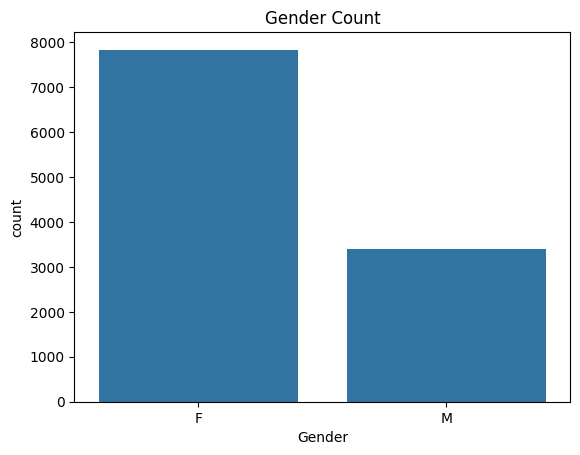

In [31]:
sns.countplot(x='Gender', data=df)
plt.title("Gender Count")
plt.show()

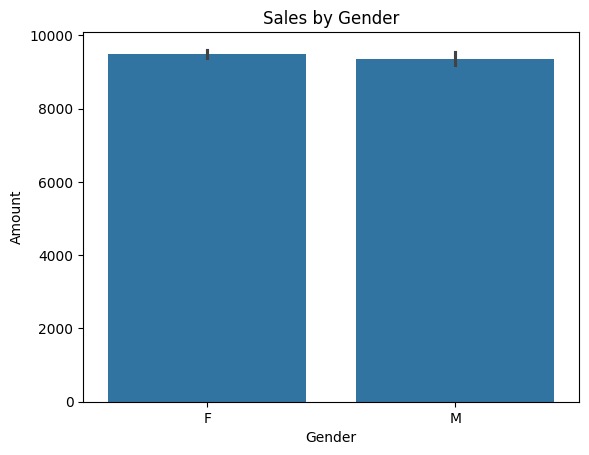

In [32]:
# Sales by Gender
sns.barplot(x='Gender', y='Amount', data=df)
plt.title("Sales by Gender")
plt.show()

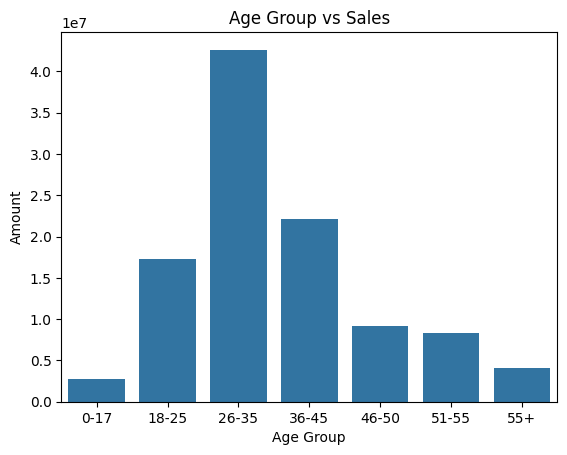

In [33]:
# Age Group vs Sales
sales_age = df.groupby('Age Group', as_index=False)['Amount'].sum()
sns.barplot(x='Age Group', y='Amount', data=sales_age)
plt.title("Age Group vs Sales")
plt.show()

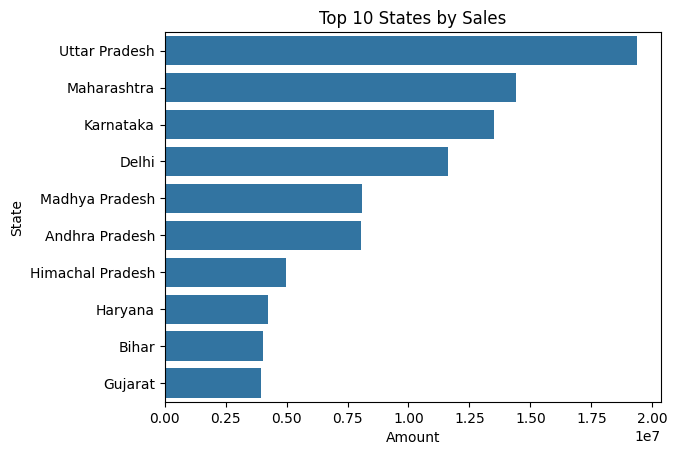

In [34]:
# Top States
sales_state = df.groupby('State', as_index=False)['Amount'].sum().sort_values(by='Amount', ascending=False).head(10)
sns.barplot(x='Amount', y='State', data=sales_state)
plt.title("Top 10 States by Sales")
plt.show()

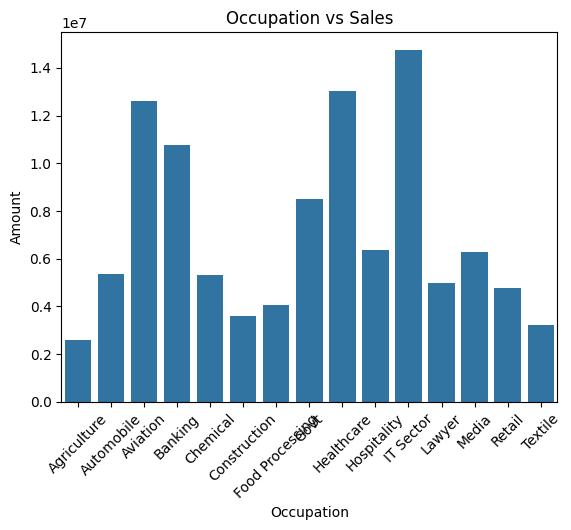

In [35]:
# Occupation vs Sales
sales_occ = df.groupby('Occupation', as_index=False)['Amount'].sum()
sns.barplot(x='Occupation', y='Amount', data=sales_occ)
plt.xticks(rotation=45)
plt.title("Occupation vs Sales")
plt.show()

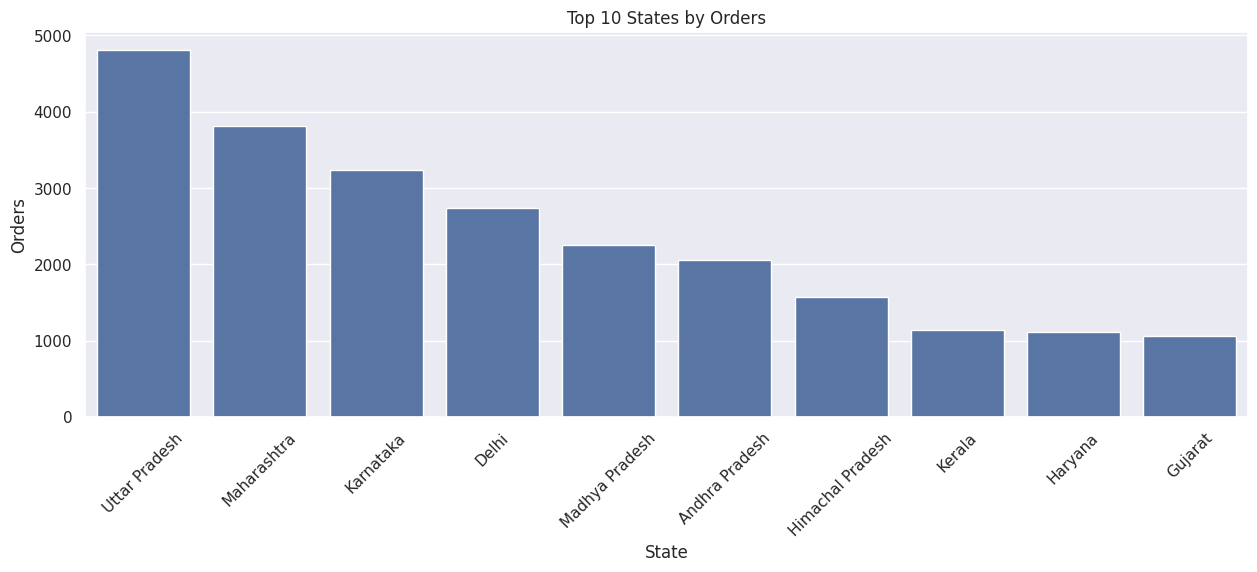

In [36]:
sales_states = df.groupby(['State'], as_index=False)['Orders'].sum() \
                 .sort_values(by='Orders', ascending=False).head(10)

sns.set(rc={'figure.figsize':(15,5)})
sns.barplot(x='State', y='Orders', data=sales_states)
plt.title("Top 10 States by Orders")
plt.xticks(rotation=45)
plt.show()

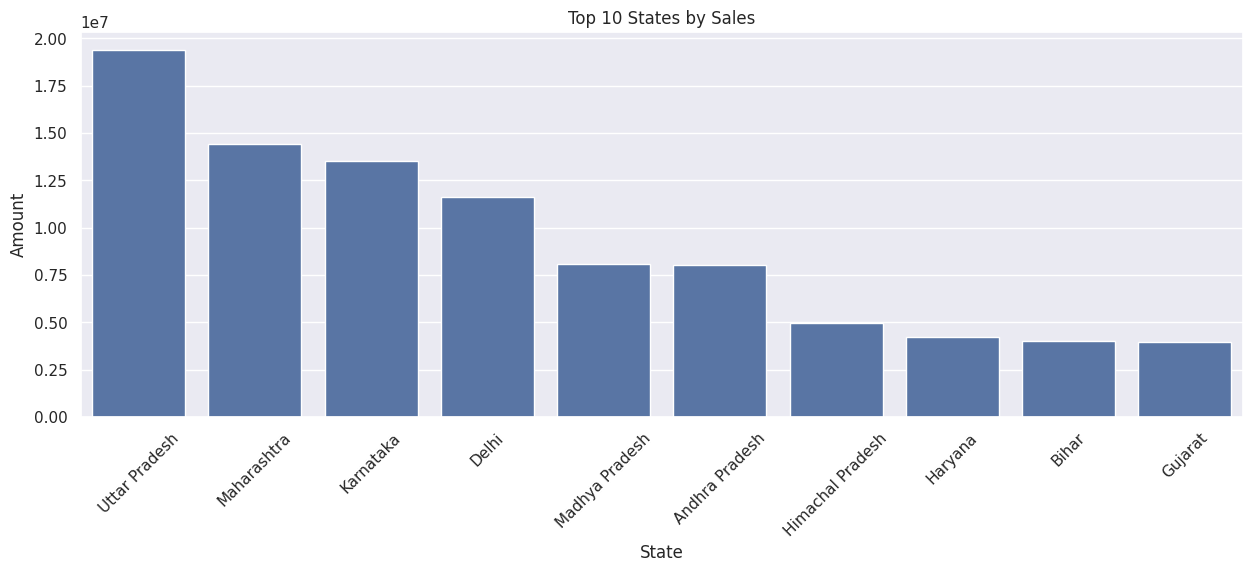

In [37]:
sales_state = df.groupby(['State'], as_index=False)['Amount'].sum() \
                .sort_values(by='Amount', ascending=False).head(10)

sns.set(rc={'figure.figsize':(15,5)})
sns.barplot(x='State', y='Amount', data=sales_state)
plt.title("Top 10 States by Sales")
plt.xticks(rotation=45)
plt.show()

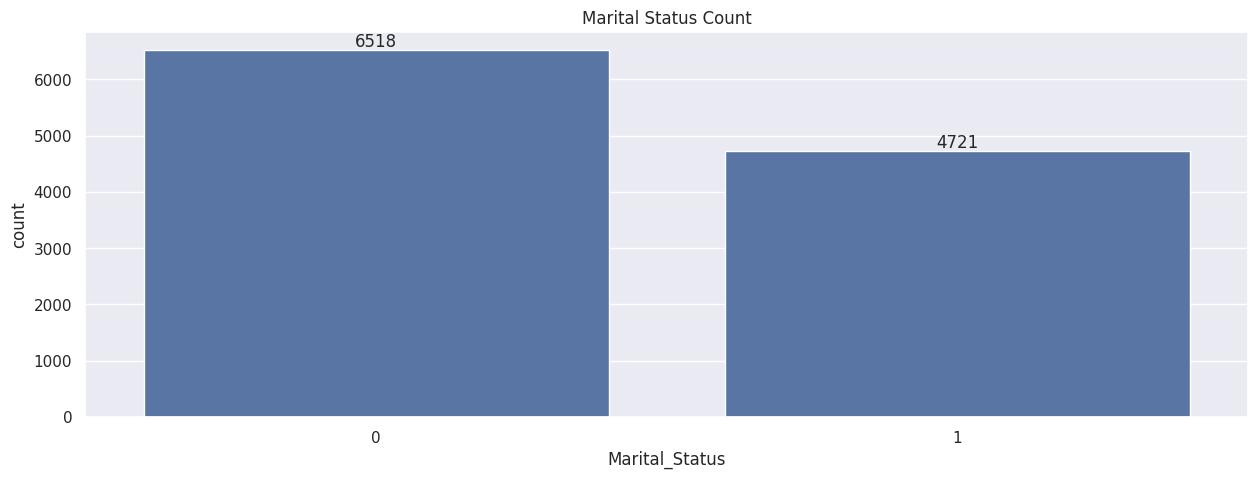

In [38]:
ax = sns.countplot(data=df, x='Marital_Status')

for bars in ax.containers:
    ax.bar_label(bars)

plt.title("Marital Status Count")
plt.show()

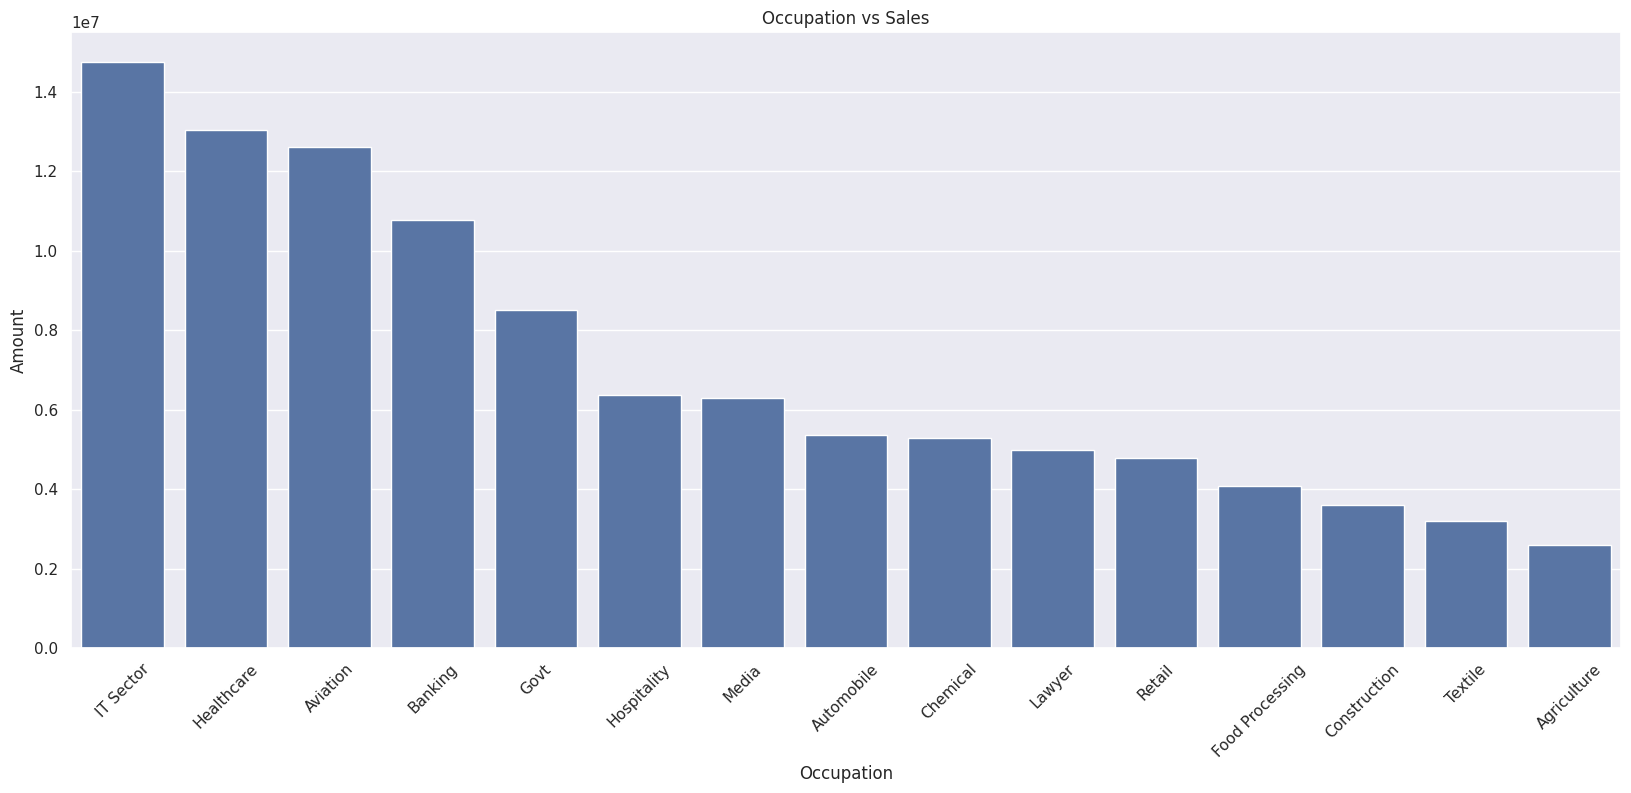

In [39]:
sns.set(rc={'figure.figsize':(20,8)})

sales_occ = df.groupby(['Occupation'], as_index=False)['Amount'].sum() \
              .sort_values(by='Amount', ascending=False)

sns.barplot(x='Occupation', y='Amount', data=sales_occ)
plt.xticks(rotation=45)
plt.title("Occupation vs Sales")
plt.show()

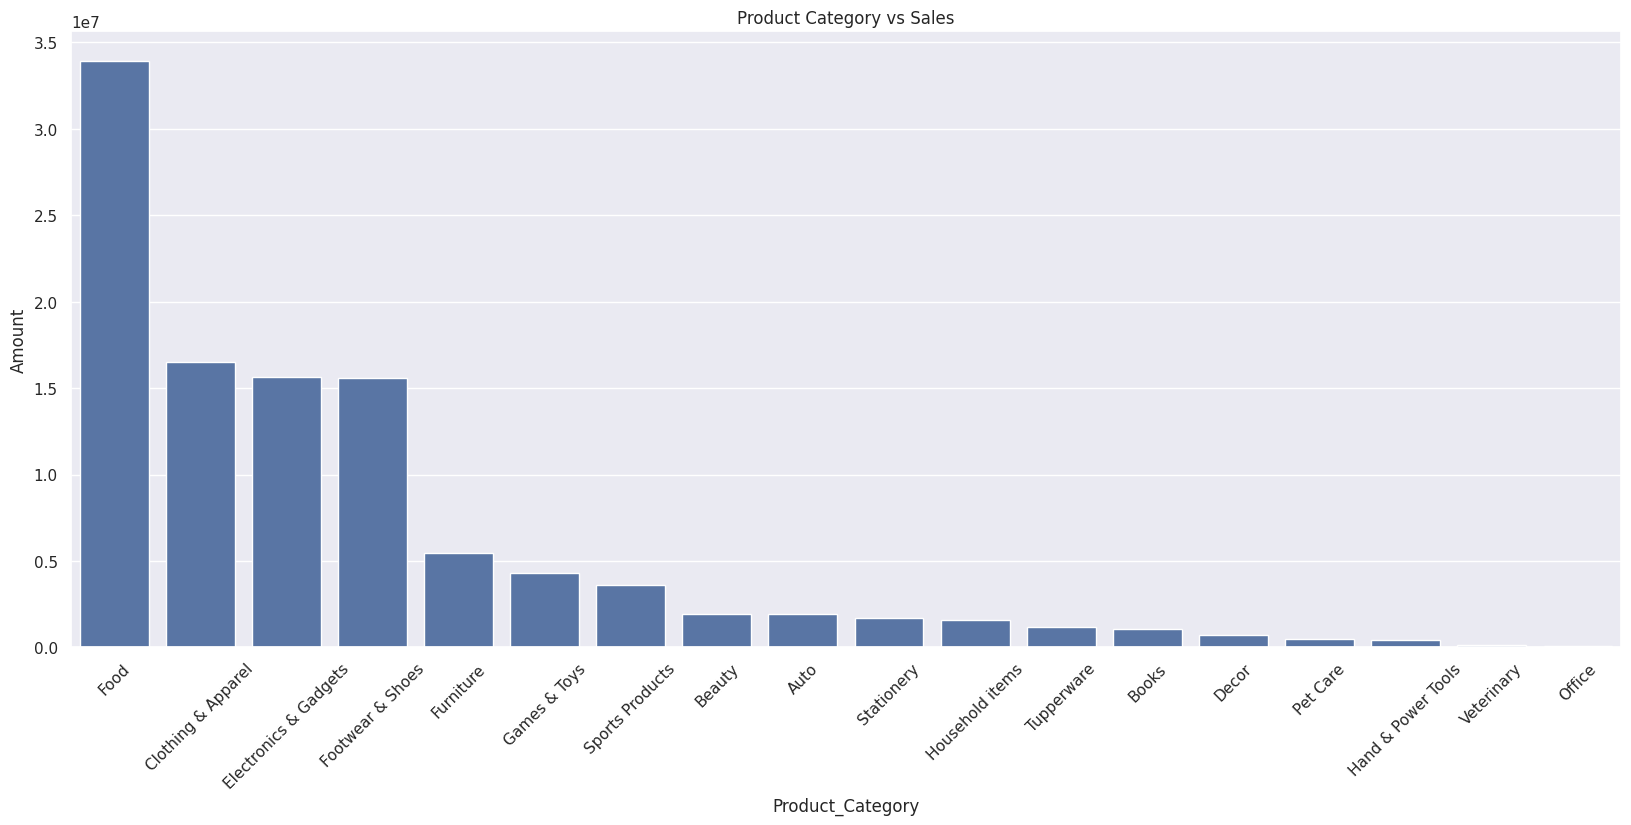

In [40]:
sales_cat = df.groupby(['Product_Category'], as_index=False)['Amount'].sum() \
              .sort_values(by='Amount', ascending=False)

sns.barplot(x='Product_Category', y='Amount', data=sales_cat)
plt.xticks(rotation=45)
plt.title("Product Category vs Sales")
plt.show()